#Evaluacion Parcial 1

### 1. Carga de Datos y Configuración Inicial

Este bloque inicializa las librerías necesarias, carga el dataset desde un archivo CSV y crea una copia del DataFrame original para trabajar con ella sin modificar la fuente.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
tabla = pd.read_csv('/data/googleplaystore.csv')
tabla.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [ ]:
df = tabla.copy()
print("DataFrame 'tabla' clonado a 'df'. Ahora puedes trabajar con 'df' independientemente.")

DataFrame 'tabla' clonado a 'df'. Ahora puedes trabajar con 'df' independientemente.


### 2. Inspección Inicial de Valores Nulos

Antes de cualquier limpieza, se realiza una inspección para identificar la cantidad de valores nulos en cada columna del DataFrame.

In [ ]:
print('Número de valores nulos por columna:')
display(tabla.isnull().sum())

Número de valores nulos por columna:


,0
App,0
Category,0
Rating,1474
Reviews,0
Size,0
Installs,0
Type,1
Price,0
Content Rating,1
Genres,0


### 3. Restauración del DataFrame y Re-aplicación de Limpieza

Este paso asegura que el DataFrame `df` se reinicie desde la copia original `tabla` y que todas las limpiezas previas para 'Rating', 'Price', 'Current Ver', y 'Android Ver' se apliquen nuevamente, lo que es útil para asegurar un estado limpio antes de proceder con otras transformaciones.

In [ ]:
# Rellenar los valores nulos de 'Rating' con la mediana por Category
df['Rating'] = df.groupby('Category')['Rating'].transform(lambda x: x.fillna(x.median()))
print("Valores nulos en 'Rating' rellenados con la mediana por Category.")

# Limpiar y convertir la columna 'Price'
df['Price'] = df['Price'].astype(str)
df['Price'] = df['Price'].str.replace('$', '', regex=False)
df['Price'] = df['Price'].str.replace('Free', '0', regex=False)
df['Price'] = pd.to_numeric(df['Price'], errors='coerce')
print("Columna 'Price' limpiada y convertida a tipo numérico.")

# Rellenar los valores nulos de 'Current Ver' con la moda por Category
df['Current Ver'] = df.groupby('Category')['Current Ver'].transform(lambda x: x.fillna(x.mode()[0] if not x.mode().empty else 'Unknown'))
print("Valores nulos en 'Current Ver' rellenados con la moda por Category (o 'Unknown' si no hay moda).")

# Rellenar los valores nulos de 'Android Ver' con 'Not Specified'
df['Android Ver'] = df['Android Ver'].fillna('Not Specified')
print("Valores nulos en 'Android Ver' rellenados con 'Not Specified'.")

Valores nulos en 'Rating' rellenados con la mediana por Category.
Columna 'Price' limpiada y convertida a tipo numérico.
Valores nulos en 'Current Ver' rellenados con la moda por Category (o 'Unknown' si no hay moda).
Valores nulos en 'Android Ver' rellenados con 'Not Specified'.


### 4. Limpieza y Conversión de 'Reviews', 'Size' e 'Installs'

Acá procedemos con la limpieza y conversión a tipos numéricos para las columnas 'Reviews', 'Size' e 'Installs', que requieren un tratamiento especial debido a sus formatos variados.

In [ ]:
# Limpiar y convertir la columna 'Reviews' a tipo numérico
df['Reviews'] = pd.to_numeric(df['Reviews'], errors='coerce')
print("Columna 'Reviews' convertida a tipo numérico.")

# Limpiar y convertir la columna 'Size' a tipo numérico (en MB)
# Función corregida para limpiar y convertir 'Size' a MB
def clean_size_corrected(size):
    if isinstance(size, str):
        if 'Varies with device' in size:
            return np.nan
        size = size.replace(',', '') # Eliminar comas
        if 'M' in size:
            return float(size.replace('M', ''))
        if 'k' in size:
            return float(size.replace('k', '')) / 1024 # Convertir KB a MB
        return np.nan # Para formatos inesperados
    return size

df['Size'] = df['Size'].apply(clean_size_corrected)
print("Columna 'Size' limpiada y convertida a tipo numérico (en MB). Los valores 'Varies with device' se han convertido a NaN.")

# Limpiar y convertir la columna 'Installs' a tipo numérico
df['Installs'] = df['Installs'].astype(str).str.replace('+', '', regex=False).str.replace(',', '', regex=False)
df['Installs'] = pd.to_numeric(df['Installs'], errors='coerce')
print("Columna 'Installs' limpiada y convertida a tipo numérico.")

Columna 'Reviews' convertida a tipo numérico.
Columna 'Size' limpiada y convertida a tipo numérico (en MB). Los valores 'Varies with device' se han convertido a NaN.
Columna 'Installs' limpiada y convertida a tipo numérico.


### 5. Verificación Final de Valores Nulos y Manejo de Filas Problemáticas

Después de todas las limpiezas, se realiza una verificación de los valores nulos restantes y se tratan filas específicas que presentan problemas de datos o inconsistencias.

In [ ]:
print('\nNúmero de valores nulos después de toda la limpieza:')
display(df.isnull().sum())


Número de valores nulos después de toda la limpieza:


,0
App,0
Category,0
Rating,0
Reviews,1
Size,1696
Installs,1
Type,1
Price,1
Content Rating,1
Genres,0


In [ ]:
print(df[df['Type'].isnull()])
print(df[df['Content Rating'].isnull()])

                            App Category  Rating  Reviews  Size  Installs  \
9148  Command & Conquer: Rivals   FAMILY     4.3      0.0   NaN       0.0   

     Type  Price Content Rating    Genres   Last Updated         Current Ver  \
9148  NaN    0.0   Everyone 10+  Strategy  June 28, 2018  Varies with device   

             Android Ver  
9148  Varies with device  
                                           App Category  Rating  Reviews  \
10472  Life Made WI-Fi Touchscreen Photo Frame      1.9    19.0      NaN   

       Size  Installs Type  Price Content Rating             Genres  \
10472   NaN       NaN    0    NaN            NaN  February 11, 2018   

      Last Updated Current Ver    Android Ver  
10472       1.0.19  4.0 and up  Not Specified  


#### 6 Identificación y Eliminación de Filas con Nulos Críticos

Se identificó una fila con valores nulos en 'Type' y otra con nulos en 'Content Rating'.

In [ ]:
# Identificar y eliminar la fila con valor nulo en 'Type'
# Basado en la inspección anterior, es la fila 9148.
df = df.dropna(subset=['Type'])
print("Fila con valor nulo en 'Type' eliminada.")

print('\nNúmero de valores nulos después de eliminar la fila con Type nulo:')
display(df.isnull().sum())

Fila con valor nulo en 'Type' eliminada.

Número de valores nulos después de eliminar la fila con Type nulo:


,0
App,0
Category,0
Rating,0
Reviews,1
Size,1695
Installs,1
Type,0
Price,1
Content Rating,1
Genres,0


Se observa que hay una fila duplicada que contiene los valores nulos en 'Type' y 'Content Rating' respectivamente.

In [ ]:
# Eliminar las filas con valores nulos en 'Type' y 'Content Rating'

df = df.drop(index=10472)
print("Fila con índice 10472 eliminada.")

# Procederemos a verificar los nulos nuevamente.
print('\nNúmero de valores nulos después de eliminar la fila 10472:')
display(df.isnull().sum())

Fila con índice 10472 eliminada.

Número de valores nulos después de eliminar la fila 10472:


,0
App,0
Category,0
Rating,0
Reviews,0
Size,1694
Installs,0
Type,0
Price,0
Content Rating,0
Genres,0


#### 7. Imputación de Valores Nulos en 'Size' por Categoría

Este bloque se encarga de calcular el porcentaje de valores nulos en la columna 'Size' por 'Category' y luego imputar estos nulos utilizando la mediana de 'Size' específica para cada categoría. Finalmente, se verifica que la imputación haya sido exitosa.

In [ ]:
size_nulls_by_category = df.groupby('Category')['Size'].apply(lambda x: x.isnull().sum())
size_total_by_category = df.groupby('Category')['Size'].apply(lambda x: len(x))

percentage_nulls_size = (size_nulls_by_category / size_total_by_category) * 100

print("Porcentaje de valores nulos en 'Size' por categoría:")
display(percentage_nulls_size.sort_values(ascending=False))

Porcentaje de valores nulos en 'Size' por categoría:


,Size
Category,
ENTERTAINMENT,39.597315
COMMUNICATION,31.524548
WEATHER,30.487805
EDUCATION,28.846154
SOCIAL,28.813559
PRODUCTIVITY,28.537736
TRAVEL_AND_LOCAL,25.581395
VIDEO_PLAYERS,25.142857
PHOTOGRAPHY,24.179104


#### 7.1 Imputación de Nulos en 'Size' con la Mediana por Categoría

Los valores nulos en 'Size' se rellenan utilizando la mediana calculada para cada 'Category'.

In [ ]:
df['Size'] = df.groupby('Category')['Size'].transform(lambda x: x.fillna(x.median()))
print("Valores nulos en 'Size' rellenados con la mediana por Category.")

Valores nulos en 'Size' rellenados con la mediana por Category.


#### 7.2 Verificación de la Imputación de 'Size'

Se comprueba el número de valores nulos restantes en la columna 'Size' para confirmar que la imputación se realizó correctamente.

In [ ]:
print("Valores nulos en la columna 'Size' después de la imputación:")
display(df['Size'].isnull().sum())

Valores nulos en la columna 'Size' después de la imputación:


np.int64(0)

### 8. Verificación y Comparación Final de DataFrames

Este bloque de código realiza una verificación exhaustiva y una comparación detallada entre el DataFrame original (`tabla`) y el DataFrame limpio y preprocesado (`df`). El objetivo es visualizar y confirmar el impacto de todas las operaciones de limpieza y transformación realizadas, analizando:


--- Comparación de Valores Nulos ---

Valores nulos en el DataFrame original 'tabla':


,0
App,0
Category,0
Rating,1474
Reviews,0
Size,0
Installs,0
Type,1
Price,0
Content Rating,1
Genres,0



Valores nulos en el DataFrame limpio 'df':


,0
App,0
Category,0
Rating,0
Reviews,0
Size,0
Installs,0
Type,0
Price,0
Content Rating,0
Genres,0



Se observa una reducción significativa de valores nulos, especialmente en 'Rating', 'Current Ver', 'Android Ver' y 'Size'.

--- Comparación de Tipos de Datos para columnas clave ---

Tipos de datos en 'tabla':


,0
Rating,float64
Reviews,object
Size,object
Installs,object
Price,object



Tipos de datos en 'df':


,0
Rating,float64
Reviews,float64
Size,float64
Installs,float64
Price,float64



Se confirma la conversión a tipos numéricos (float64) para 'Rating', 'Reviews', 'Size', 'Installs' y 'Price' en el DataFrame 'df'.

--- Visualización de Distribución de 'Rating' ---


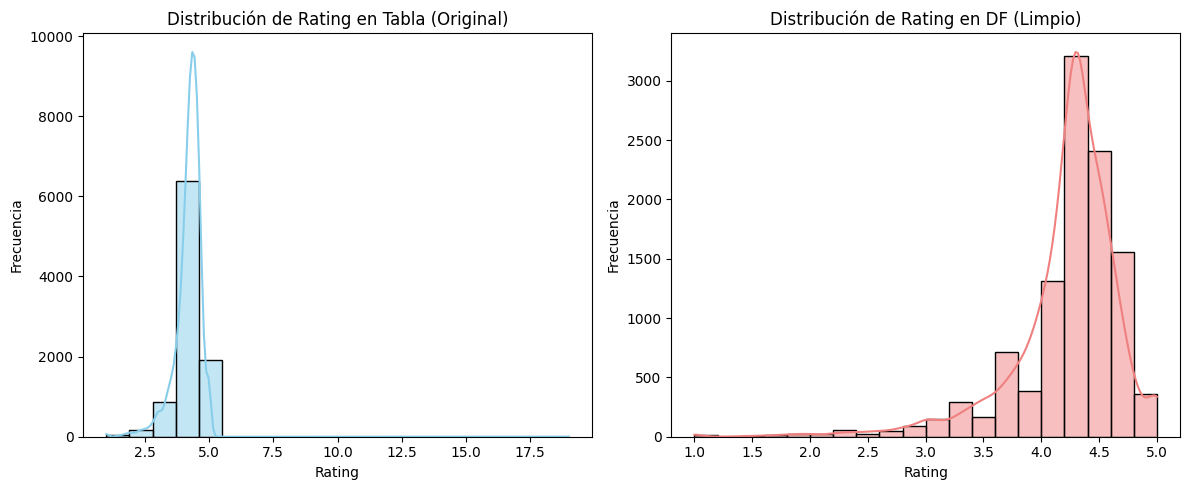

Se observa cómo la imputación de la mediana ha rellenado los vacíos y, posiblemente, suavizado la distribución de 'Rating'.

--- Visualización de Distribución de 'Size' ---


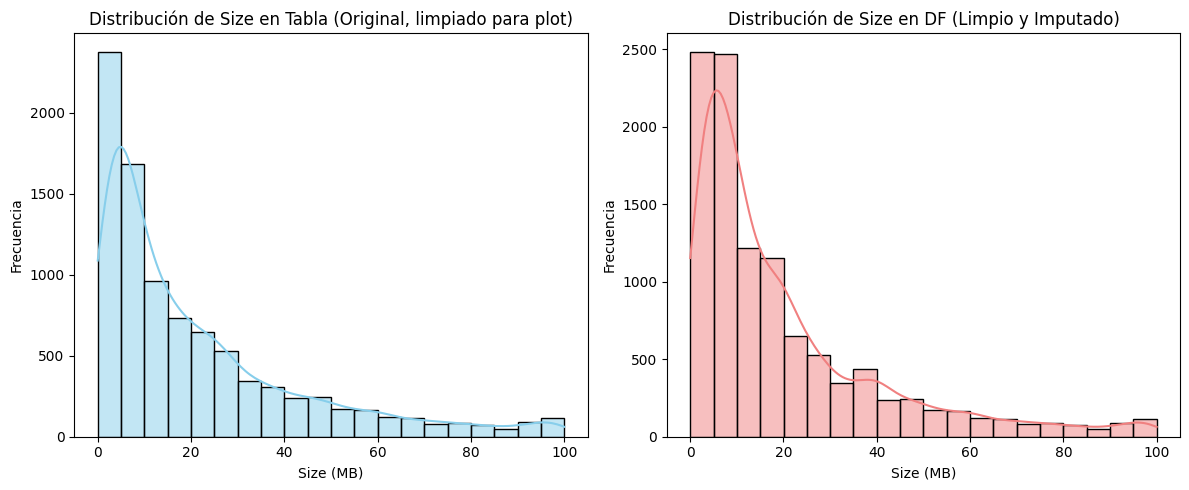

La distribución de 'Size' en 'df' muestra la imputación de valores nulos, resultando en una distribución más completa y menos dispersa después de manejar 'Varies with device' y convertir a numérico.

--- Visualización de Distribución de 'Price' ---


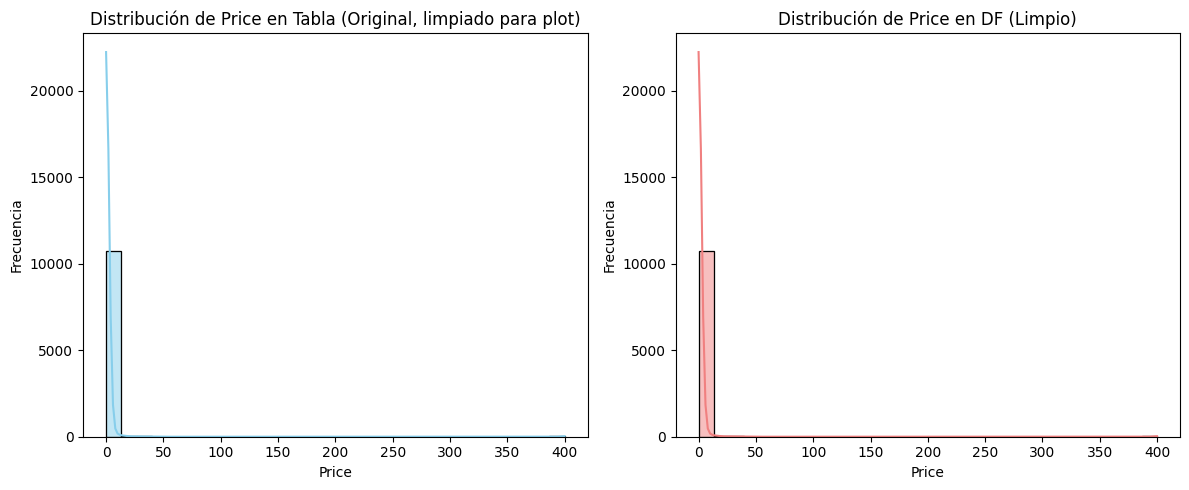

La distribución de 'Price' en 'df' ahora es numéricamente representable, con 'Free' convertido a 0, facilitando el análisis.

--- Resumen de la Comparación entre 'tabla' y 'df' ---
El proceso de limpieza y preprocesamiento ha mejorado significativamente la calidad y usabilidad de los datos:
1.  **Reducción de Valores Nulos**: Todos los valores nulos críticos en 'Rating', 'Current Ver', 'Android Ver', y 'Size' han sido imputados o eliminados, haciendo que `df` sea un conjunto de datos más completo.
2.  **Conversión de Tipos de Datos**: Columnas como 'Rating', 'Reviews', 'Size', 'Installs' y 'Price' se han convertido exitosamente a tipos numéricos (float64), lo que permite análisis cuantitativos y cálculos.
3.  **Distribuciones Limpias y Coherentes**: Las visualizaciones muestran que las distribuciones de 'Rating', 'Size' y 'Price' son ahora más consistentes y están libres de artefactos de datos brutos, como cadenas de texto o valores atípicos no manejados.
En general, `df` representa un

In [ ]:
# 1. Comparar Valores Nulos
print("--- Comparación de Valores Nulos ---")
print("\nValores nulos en el DataFrame original 'tabla':")
display(tabla.isnull().sum())

print("\nValores nulos en el DataFrame limpio 'df':")
display(df.isnull().sum())

print("\nSe observa una reducción significativa de valores nulos, especialmente en 'Rating', 'Current Ver', 'Android Ver' y 'Size'.")

# 2. Comparar Tipos de Datos
print("\n--- Comparación de Tipos de Datos para columnas clave ---")
key_columns = ['Rating', 'Reviews', 'Size', 'Installs', 'Price']

print("\nTipos de datos en 'tabla':")
display(tabla[key_columns].dtypes)

print("\nTipos de datos en 'df':")
display(df[key_columns].dtypes)

print("\nSe confirma la conversión a tipos numéricos (float64) para 'Rating', 'Reviews', 'Size', 'Installs' y 'Price' en el DataFrame 'df'.")

# Preparar datos temporales de 'tabla' para visualización de 'Size' y 'Price'
def clean_size_for_plotting(size):
    if isinstance(size, str):
        if 'Varies with device' in size:
            return np.nan
        size = size.replace(',', '') # Eliminar comas
        if 'M' in size:
            return float(size.replace('M', ''))
        if 'k' in size:
            return float(size.replace('k', '')) / 1024 # Convertir KB a MB
        return np.nan
    return size # Retorna NaN si ya es NaN o si es otro tipo no manejado

tabla_size_cleaned_for_plot = tabla['Size'].apply(clean_size_for_plotting)

# Para Price en tabla (original), necesitamos limpiarlo para poder plotearlo numéricamente
tabla_price_cleaned_for_plot = tabla['Price'].astype(str).str.replace('$', '', regex=False).str.replace('Free', '0', regex=False)
tabla_price_cleaned_for_plot = pd.to_numeric(tabla_price_cleaned_for_plot, errors='coerce')


# 3. Visualizar Distribución de 'Rating'
print("\n--- Visualización de Distribución de 'Rating' ---")
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(tabla['Rating'].dropna(), kde=True, bins=20, color='skyblue')
plt.title('Distribución de Rating en Tabla (Original)')
plt.xlabel('Rating')
plt.ylabel('Frecuencia')

plt.subplot(1, 2, 2)
sns.histplot(df['Rating'], kde=True, bins=20, color='lightcoral')
plt.title('Distribución de Rating en DF (Limpio)')
plt.xlabel('Rating')
plt.ylabel('Frecuencia')

plt.tight_layout()
plt.show()
print("Se observa cómo la imputación de la mediana ha rellenado los vacíos y, posiblemente, suavizado la distribución de 'Rating'.")


# 4. Visualizar Distribución de 'Size'
print("\n--- Visualización de Distribución de 'Size' ---")
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(tabla_size_cleaned_for_plot.dropna(), kde=True, bins=20, color='skyblue')
plt.title('Distribución de Size en Tabla (Original, limpiado para plot)')
plt.xlabel('Size (MB)')
plt.ylabel('Frecuencia')

plt.subplot(1, 2, 2)
sns.histplot(df['Size'].dropna(), kde=True, bins=20, color='lightcoral')
plt.title('Distribución de Size en DF (Limpio y Imputado)')
plt.xlabel('Size (MB)')
plt.ylabel('Frecuencia')

plt.tight_layout()
plt.show()
print("La distribución de 'Size' en 'df' muestra la imputación de valores nulos, resultando en una distribución más completa y menos dispersa después de manejar 'Varies with device' y convertir a numérico.")


# 5. Visualizar Distribución de 'Price'
print("\n--- Visualización de Distribución de 'Price' ---")
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(tabla_price_cleaned_for_plot.dropna(), kde=True, bins=30, color='skyblue')
plt.title('Distribución de Price en Tabla (Original, limpiado para plot)')
plt.xlabel('Price')
plt.ylabel('Frecuencia')

plt.subplot(1, 2, 2)
sns.histplot(df['Price'].dropna(), kde=True, bins=30, color='lightcoral')
plt.title('Distribución de Price en DF (Limpio)')
plt.xlabel('Price')
plt.ylabel('Frecuencia')

plt.tight_layout()
plt.show()
print("La distribución de 'Price' en 'df' ahora es numéricamente representable, con 'Free' convertido a 0, facilitando el análisis.")


# 6. Resumen de la Comparación
print("\n--- Resumen de la Comparación entre 'tabla' y 'df' ---")
print("El proceso de limpieza y preprocesamiento ha mejorado significativamente la calidad y usabilidad de los datos:")
print("1.  **Reducción de Valores Nulos**: Todos los valores nulos críticos en 'Rating', 'Current Ver', 'Android Ver', y 'Size' han sido imputados o eliminados, haciendo que `df` sea un conjunto de datos más completo.")
print("2.  **Conversión de Tipos de Datos**: Columnas como 'Rating', 'Reviews', 'Size', 'Installs' y 'Price' se han convertido exitosamente a tipos numéricos (float64), lo que permite análisis cuantitativos y cálculos.")
print("3.  **Distribuciones Limpias y Coherentes**: Las visualizaciones muestran que las distribuciones de 'Rating', 'Size' y 'Price' son ahora más consistentes y están libres de artefactos de datos brutos, como cadenas de texto o valores atípicos no manejados.")
print("En general, `df` representa un conjunto de datos mucho más limpio y listo para el análisis en comparación con el `tabla` original.")


In [ ]:
df.to_csv('googleplaystore_limpio.csv', index=False)
print("DataFrame 'df' exportado exitosamente a 'googleplaystore_limpio.csv'.")

DataFrame 'df' exportado exitosamente a 'googleplaystore_limpio.csv'.


#Evaluacion Parcial 2

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
tabla = pd.read_csv('googleplaystore.csv')
tabla.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [ ]:
print('Número de valores nulos por columna:')
display(tabla.isnull().sum())

Número de valores nulos por columna:


,0
App,0
Category,0
Rating,1474
Reviews,0
Size,0
Installs,0
Type,1
Price,0
Content Rating,1
Genres,0


### 9. Modelado Supervisado

Para implementar múltiples modelos supervisados usando `Pipelines`, seguiremos los siguientes pasos:

1.  **Definir el Problema**: Identificar la variable objetivo (target) y las características (features) relevantes.
2.  **Preprocesamiento de Datos**: Aplicar transformaciones a las características numéricas y categóricas (escalado, codificación, imputación, etc.) utilizando `ColumnTransformer`.
3.  **Selección de Modelos**: Escoger varios algoritmos de aprendizaje supervisado (por ejemplo, Regresión Logística, Random Forest, Gradient Boosting).
4.  **Creación de Pipelines**: Construir un `Pipeline` para cada modelo, encapsulando el preprocesamiento y el modelo final.
5.  **Entrenamiento y Evaluación**: Entrenar los pipelines y evaluar su rendimiento utilizando métricas adecuadas (por ejemplo, accuracy, precision, recall, F1-score, ROC-AUC).
6.  **Optimización de Hiperparámetros**: Opcionalmente, usar `GridSearchCV` o `RandomizedSearchCV` para optimizar los hiperparámetros de los mejores modelos.

Utilizaremos el DataFrame `df` que ya ha sido limpiado y preprocesado.

### 9.1 Definición del Problema: Variable Objetivo y Características

Primero, necesitamos identificar cuál será nuestra variable objetivo (y) y cuáles serán las características (X) que utilizaremos para predecirla. Para este ejemplo, vamos a intentar predecir la columna `Rating` como una tarea de regresión. Dado que `Rating` es un valor continuo, lo trataremos como tal. Convertiremos `Rating` a una variable categórica para una clasificación simplificada (por ejemplo, 'High Rating' vs 'Low Rating') o usaremos una regresión para predecir el valor exacto. Dado que `Rating` tiene un rango de 1 a 5, podríamos categorizarlo. Por ejemplo, `Rating >= 4.0` como 'Bueno' y `Rating < 4.0` como 'Regular'.

**Variables a usar:**
*   **Variable Objetivo (y):** `Rating` (convertida a categórica si es clasificación, o directamente para regresión).
*   **Características (X):** Seleccionaremos columnas relevantes que puedan influir en el rating de una aplicación.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Vamos a categorizar la columna 'Rating' para una tarea de clasificación binaria:
# 'High_Rating' si Rating >= 4.0, 'Low_Rating' si Rating < 4.0
df['Rating_Category'] = df['Rating'].apply(lambda x: 'High_Rating' if x >= 4.0 else 'Low_Rating')

# Definir características (X) y variable objetivo (y)
X = df.drop(['App', 'Rating', 'Rating_Category', 'Last Updated', 'Current Ver', 'Android Ver', 'Genres'], axis=1)
y = df['Rating_Category'] # Usaremos la categoría como objetivo para este ejemplo

# Identificar columnas numéricas y categóricas
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X.select_dtypes(include=['object']).columns

print("Características Numéricas:", numeric_features.tolist())
print("Características Categóricas:", categorical_features.tolist())

# Dividir los datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nTamaño del conjunto de entrenamiento: {X_train.shape[0]} muestras")
print(f"Tamaño del conjunto de prueba: {X_test.shape[0]} muestras")
print(f"Distribución de la variable objetivo en el entrenamiento:\n{y_train.value_counts(normalize=True)}")
print(f"Distribución de la variable objetivo en la prueba:\n{y_test.value_counts(normalize=True)}")

Características Numéricas: ['Reviews', 'Size', 'Installs', 'Price']
Características Categóricas: ['Category', 'Type', 'Content Rating']

Tamaño del conjunto de entrenamiento: 8671 muestras
Tamaño del conjunto de prueba: 2168 muestras
Distribución de la variable objetivo en el entrenamiento:
Rating_Category
High_Rating    0.815708
Low_Rating     0.184292
Name: proportion, dtype: float64
Distribución de la variable objetivo en la prueba:
Rating_Category
High_Rating    0.815498
Low_Rating     0.184502
Name: proportion, dtype: float64


### 9.2 Preprocesamiento de Datos con `ColumnTransformer`

Para el preprocesamiento, aplicaremos:
*   **Escalado Numérico**: Usaremos `StandardScaler` para estandarizar las características numéricas.
*   **Codificación Categórica**: Usaremos `OneHotEncoder` para convertir las características categóricas en un formato numérico adecuado para los modelos.

In [ ]:
# Crear el preprocesador para las columnas numéricas y categóricas
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

print("Preprocesador 'ColumnTransformer' configurado exitosamente.")
print("Transformadores aplicados:")
for name, transformer, cols in preprocessor.transformers:
    print(f"- {name}: {transformer.__class__.__name__} a las columnas {cols.tolist()}")

Preprocesador 'ColumnTransformer' configurado exitosamente.
Transformadores aplicados:
- num: StandardScaler a las columnas ['Reviews', 'Size', 'Installs', 'Price']
- cat: OneHotEncoder a las columnas ['Category', 'Type', 'Content Rating']


### 9.3 Selección de Modelos y Creación de Pipelines

Ahora, definiremos varios modelos de clasificación y los incorporaremos en `Pipelines` junto con el preprocesador que acabamos de configurar. Esto nos permitirá tener un flujo de trabajo modular y replicable para cada modelo.